# Nifty 500 Five Years EDA Project

## 1. Objective
- Analyze Nifty 500 activity over last 5 years.
- How do dails and monthly returns looks like.
- How has volatility behaves across 5 years.
- What were the worst drawdowns

## 2. Dataset Description
- Source Kaggle : " Nifty500 companies 5 years stock market data ".
- Daily OHLCV data for all 500 NSE-listed stocks from June 2021 to June 2026.
- The dataset has 551,643 rows and 8 columns : Date, Ticker, Open, High, Low, Close, Volume, and Notes.

## 3.Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_style = "whitegrid"
sns.set_palette = "muted"
plt.rcParams["figure.figsize"] = (10,6)

## 4. Load Data

In [2]:
df = pd.read_csv("../data/nifty500_5yr_data.csv")

df.shape

(551643, 8)

In [3]:
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Notes
0,2021-06-09,360ONE,260.813755,262.150806,249.887157,251.816010,59152.0,NaN
1,2021-06-10,360ONE,253.997012,260.046642,251.848943,257.131409,41084.0,NaN
2,2021-06-11,360ONE,259.443804,263.246739,256.714877,260.758942,232800.0,NaN
3,2021-06-14,360ONE,261.931602,263.027550,258.939658,259.619141,74364.0,NaN
4,2021-06-15,360ONE,260.791773,260.791773,252.144728,253.821533,149636.0,NaN


## 5. Basic Inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551643 entries, 0 to 551642
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    551643 non-null  str    
 1   Ticker  551643 non-null  str    
 2   Open    551643 non-null  float64
 3   High    551643 non-null  float64
 4   Low     551643 non-null  float64
 5   Close   551643 non-null  float64
 6   Volume  551643 non-null  float64
 7   Notes   465 non-null     str    
dtypes: float64(5), str(3)
memory usage: 33.7 MB


In [5]:
df.describe()

,Open,High,Low,Close,Volume
count,551643.000000,551643.000000,551643.000000,551643.000000,5.516430e+05
mean,1882.927583,1908.446096,1855.072520,1880.521817,5.929137e+06
std,6610.161851,6678.209196,6531.022663,6600.118226,2.790023e+07
min,3.500000,3.650000,3.350000,3.500000,2.370000e+02
25%,246.780998,251.451467,242.128479,246.402252,2.484385e+05
50%,631.138124,641.790427,620.500000,630.408203,8.441400e+05
75%,1470.415559,1492.066060,1447.570744,1468.885010,3.261656e+06
max,161973.590589,163593.537167,160278.657659,162288.578125,1.807991e+09


In [6]:
df.isna().sum()

Date           0
Ticker         0
Open           0
High           0
Low            0
Close          0
Volume         0
Notes     551178
dtype: int64

In [7]:
df["Notes"].notna().sum()

np.int64(465)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates().shape[0]

551643

In [10]:
df.dtypes

Date          str
Ticker        str
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
Notes         str
dtype: object

### Intial Inspection Notes

- DataFrame has 551643 rows and 8 columns in total.
- Columns are : Date, Ticker, Open, High, Low, Close, Volume, and Notes.
- Only Notes Column have null values i.e. 551178, which means that there total 465 non-null values.
- There are no duplicated rows and columns.
- Date column is in string and have to be converted in proper date_time data type.


## 6. Data Cleaning & Feature Engineering

In [11]:
df.columns.to_list()

['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'Notes']

In [12]:
# Convert all columns to snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')


In [13]:
df = df.round(2)

In [14]:
df["date"].head()

0    2021-06-09
1    2021-06-10
2    2021-06-11
3    2021-06-14
4    2021-06-15
Name: date, dtype: str

In [15]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [16]:
df["date"].dtype

dtype('<M8[us]')

In [17]:
df["date"].head()

0   2021-06-09
1   2021-06-09
2   2021-06-09
3   2021-06-09
4   2021-06-09
Name: date, dtype: datetime64[us]

- Date columns is converted to date_time data type and also sorted 

In [18]:
df["date"].isna().sum()

np.int64(0)

- There are no missing values in Date column

In [19]:
df.duplicated(subset = ["ticker","date"]).sum()

np.int64(0)

- There is no company's data appearing more than 1 time in a day

In [20]:
df.drop(columns=["notes"],inplace=True)

- notes are not a part of stock data and should removed

In [21]:
df["daily_returns"] = df.groupby("ticker")["close"].transform(lambda x : x.pct_change())
df.head()

,date,ticker,open,high,low,close,volume,daily_returns
0,2021-06-09,360ONE,260.81,262.15,249.89,251.82,59152.0,NaN
1,2021-06-09,POWERGRID,102.61,106.74,101.65,105.26,39865778.0,NaN
2,2021-06-09,APOLLOHOSP,3247.54,3288.60,3209.04,3263.23,587528.0,NaN
3,2021-06-09,PFC,72.86,77.43,72.48,75.34,30709618.0,NaN
4,2021-06-09,POONAWALLA,150.41,160.69,150.31,153.52,1287412.0,NaN


- Added a new columns `daily_returns` which tell pecentage change in the price from previous day's close price

In [22]:
df["log_return"] = df.groupby("ticker")["close"].transform(lambda x: np.log(x).diff())
df.head()

,date,ticker,open,high,low,close,volume,daily_returns,log_return
0,2021-06-09,360ONE,260.81,262.15,249.89,251.82,59152.0,NaN,NaN
1,2021-06-09,POWERGRID,102.61,106.74,101.65,105.26,39865778.0,NaN,NaN
2,2021-06-09,APOLLOHOSP,3247.54,3288.60,3209.04,3263.23,587528.0,NaN,NaN
3,2021-06-09,PFC,72.86,77.43,72.48,75.34,30709618.0,NaN,NaN
4,2021-06-09,POONAWALLA,150.41,160.69,150.31,153.52,1287412.0,NaN,NaN


- Added a new columns `log_return`, measures the logarithmic change from one row to the next in Close.

In [23]:

df["rolling_mean_20"] = (
    df.groupby("ticker")["close"]
      .transform(lambda x: x.rolling(20).mean())
)
df.head()

,date,ticker,open,high,low,close,volume,daily_returns,log_return,rolling_mean_20
0,2021-06-09,360ONE,260.81,262.15,249.89,251.82,59152.0,NaN,NaN,NaN
1,2021-06-09,POWERGRID,102.61,106.74,101.65,105.26,39865778.0,NaN,NaN,NaN
2,2021-06-09,APOLLOHOSP,3247.54,3288.60,3209.04,3263.23,587528.0,NaN,NaN,NaN
3,2021-06-09,PFC,72.86,77.43,72.48,75.34,30709618.0,NaN,NaN,NaN
4,2021-06-09,POONAWALLA,150.41,160.69,150.31,153.52,1287412.0,NaN,NaN,NaN


- Added a new column `rolling_mean_20` of window length 20, it calculates the 20 period moving average.

In [24]:
df["rolling_vol_20"] = df.groupby("ticker")["daily_returns"].transform(lambda x : x.rolling(20).std())
df.head()

,date,ticker,open,high,low,close,volume,daily_returns,log_return,rolling_mean_20,rolling_vol_20
0,2021-06-09,360ONE,260.81,262.15,249.89,251.82,59152.0,NaN,NaN,NaN,NaN
1,2021-06-09,POWERGRID,102.61,106.74,101.65,105.26,39865778.0,NaN,NaN,NaN,NaN
2,2021-06-09,APOLLOHOSP,3247.54,3288.60,3209.04,3263.23,587528.0,NaN,NaN,NaN,NaN
3,2021-06-09,PFC,72.86,77.43,72.48,75.34,30709618.0,NaN,NaN,NaN,NaN
4,2021-06-09,POONAWALLA,150.41,160.69,150.31,153.52,1287412.0,NaN,NaN,NaN,NaN


- Added a new column `rolling_vol_20` used as rolling volatility, each row gets the standard deviation of the most recent 20 daily returns.

In [25]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [26]:
df.head()

,date,ticker,open,high,low,close,volume,daily_returns,log_return,rolling_mean_20,rolling_vol_20,year,month
0,2021-06-09,360ONE,260.81,262.15,249.89,251.82,59152.0,NaN,NaN,NaN,NaN,2021,6
1,2021-06-09,POWERGRID,102.61,106.74,101.65,105.26,39865778.0,NaN,NaN,NaN,NaN,2021,6
2,2021-06-09,APOLLOHOSP,3247.54,3288.60,3209.04,3263.23,587528.0,NaN,NaN,NaN,NaN,2021,6
3,2021-06-09,PFC,72.86,77.43,72.48,75.34,30709618.0,NaN,NaN,NaN,NaN,2021,6
4,2021-06-09,POONAWALLA,150.41,160.69,150.31,153.52,1287412.0,NaN,NaN,NaN,NaN,2021,6


In [27]:
df["running_max"] = df.groupby("ticker")["close"].cummax()
df["drawdown"] = (df["close"] - df["running_max"])/df["running_max"]

In [28]:
df.head()

,date,ticker,open,high,low,close,volume,daily_returns,log_return,rolling_mean_20,rolling_vol_20,year,month,running_max,drawdown
0,2021-06-09,360ONE,260.81,262.15,249.89,251.82,59152.0,NaN,NaN,NaN,NaN,2021,6,251.82,0.0
1,2021-06-09,POWERGRID,102.61,106.74,101.65,105.26,39865778.0,NaN,NaN,NaN,NaN,2021,6,105.26,0.0
2,2021-06-09,APOLLOHOSP,3247.54,3288.60,3209.04,3263.23,587528.0,NaN,NaN,NaN,NaN,2021,6,3263.23,0.0
3,2021-06-09,PFC,72.86,77.43,72.48,75.34,30709618.0,NaN,NaN,NaN,NaN,2021,6,75.34,0.0
4,2021-06-09,POONAWALLA,150.41,160.69,150.31,153.52,1287412.0,NaN,NaN,NaN,NaN,2021,6,153.52,0.0


### Data Cleaning & Feature Engineering Summary

- Columns are converted to snake_case format.
- date was in string data type, so changed to date_time data type ans also sorted.
- There are no missing values in the columns.
- There is no company's data appearing more than 1 time in a day.
- The note column was not part of stock data so it was removed.
- New Columns were added:
   - daily_returns
   - log_return
   - rolling_mean_20
   - rolling_vol_20
   - year
   - month
   - running_max
   - drawdown

# 7. Univariate Analysis 
In this section we analyze indivisual variables, there frequency, there distribution and overall pattern.

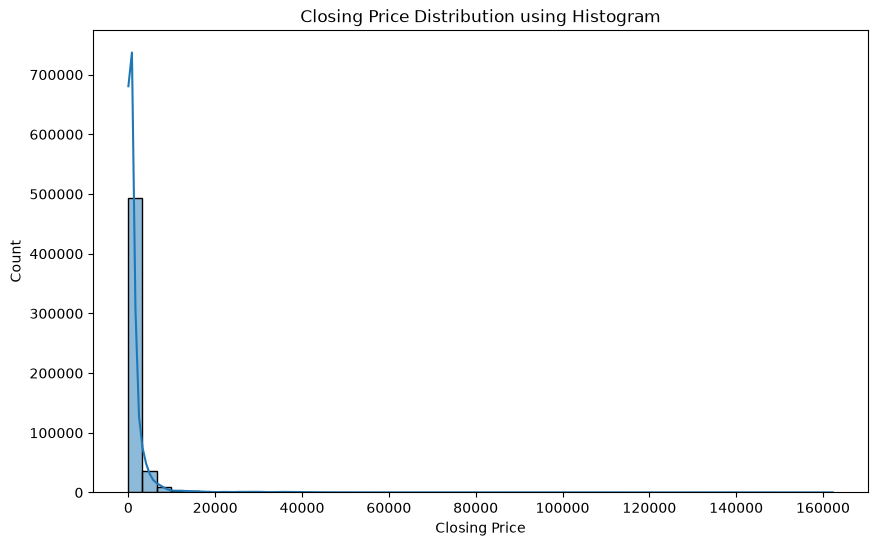

In [29]:
sns.histplot(df["close"].dropna(),bins = 50 , kde= True)
plt.ylabel("Count")
plt.xlabel("Closing Price")
plt.title("Closing Price Distribution using Histogram")
plt.show()

 - The close price distribution is highly right-skewed which signifies that there are very samll number of stock prices that are high in price, most of them fall under mid range 

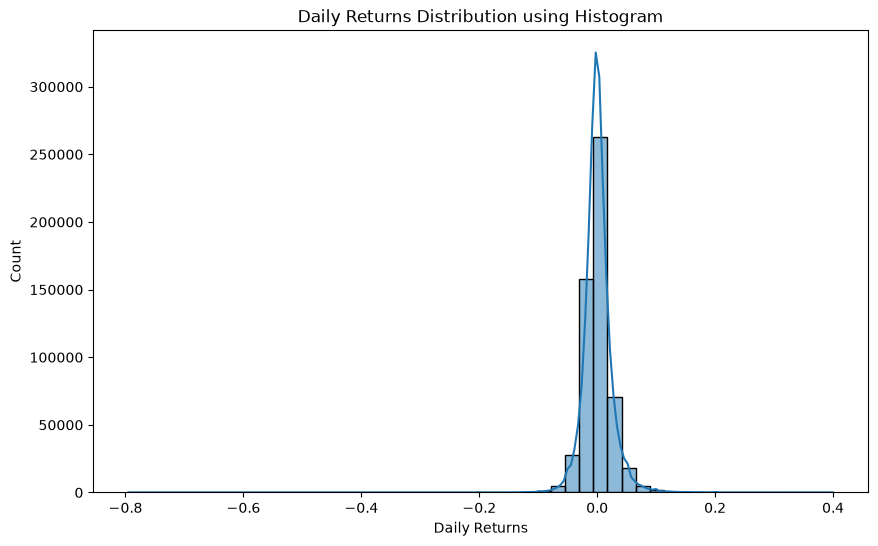

In [30]:
sns.histplot(df["daily_returns"].dropna(), bins = 50, kde = True)
plt.xlabel("Daily Returns")
plt.ylabel("Count")
plt.title("Daily Returns Distribution using Histogram")
plt.show()

- The distribution is centered at zero, so genrally the daily moves are small, with some positive and negative outliers.
- It is concentrated with in a small range showing a tight concentration within a range.

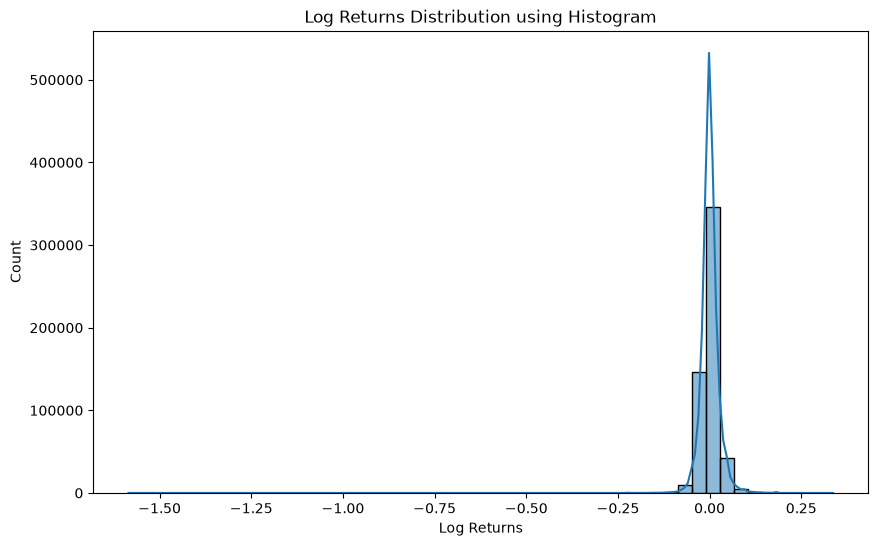

In [31]:
sns.histplot(df["log_return"].dropna(), bins = 50, kde = True)
plt.xlabel("Log Returns")
plt.ylabel("Count")
plt.title("Log Returns Distribution using Histogram")
plt.show()

- Same as daily_return its is also centred at zero indicating small daily moves with poisitve and negative outliers.(more negative outliers that creates that long left tail)

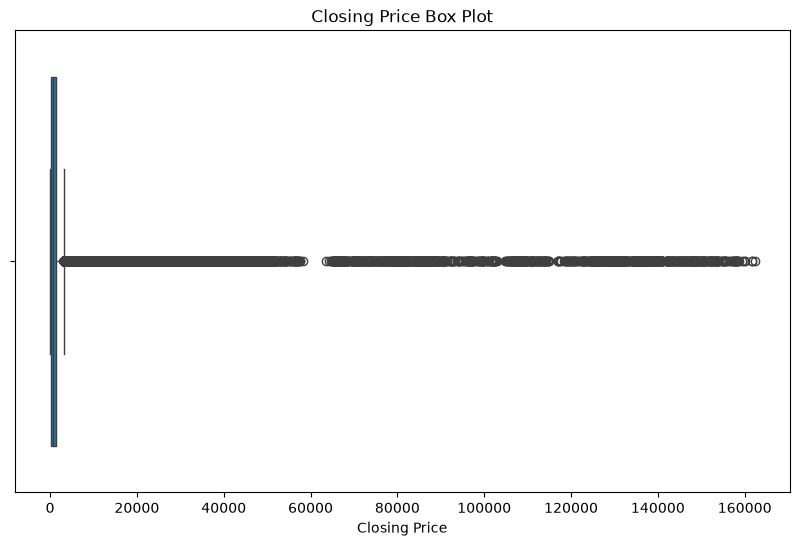

In [32]:
sns.boxplot(x=df["close"])
plt.xlabel("Closing Price")
plt.title("Closing Price Box Plot")
plt.show()

- The box plot is right-skewed, again showing that the very small amount of stock have very large close price whereas majority lies in very small range

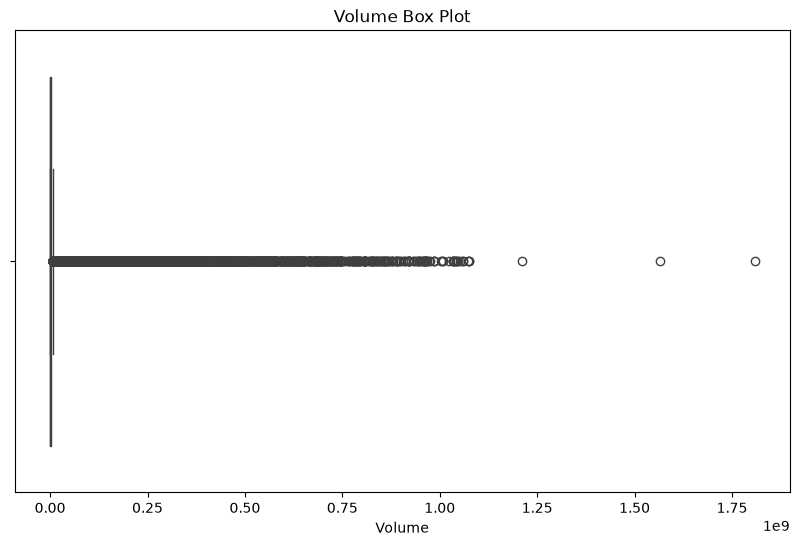

In [33]:
sns.boxplot(x=df["volume"])
plt.xlabel("Volume")
plt.title("Volume Box Plot")
plt.show()

-  The box plot is signifying a few stock stocks are selled at very large volumes with some outliers.

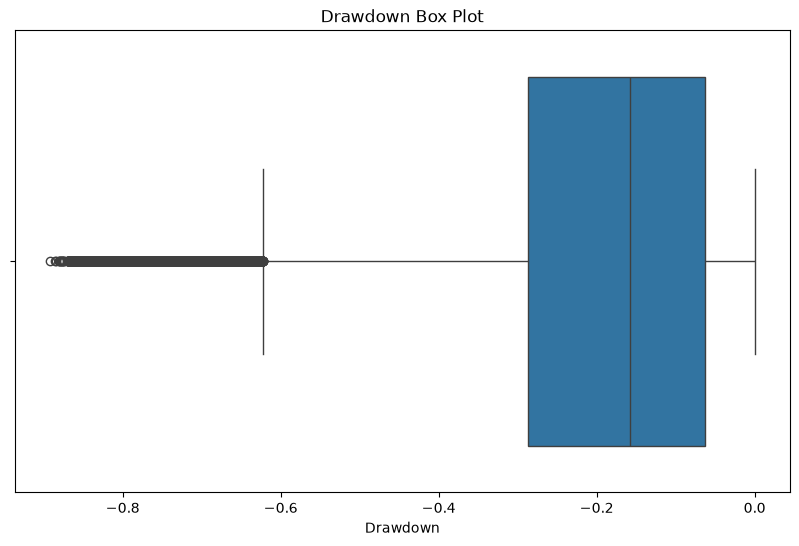

In [34]:
sns.boxplot(x=df["drawdown"])
plt.xlabel("Drawdown")
plt.title("Drawdown Box Plot")
plt.show()

- 50% of the observations lies between -0.25 to -0.1, which means 50% of the data exprience -25% to -10% drawdown.

### Key Findings from Univariate Analysis


- The close price distribution is highly right-skewed.
- Daily returns and Log returns are centered at zero.
- 50% of the data exprience -25% to -10% drawdown.

# 8. Bivariate Analysis
In this section, we explore relationships between two variables at a time to answer the core questions of this analysis.

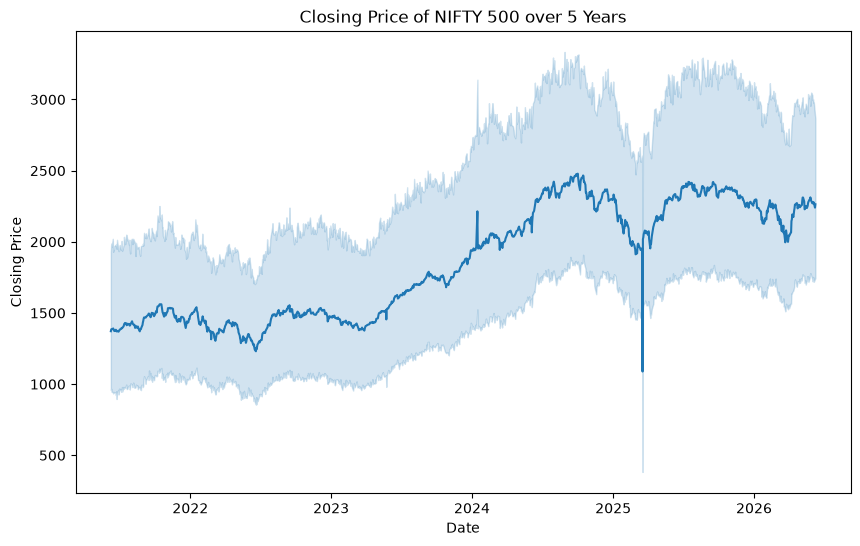

In [35]:
#date vs close price trend
sns.lineplot(data = df, x ="date", y="close")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Closing Price of NIFTY 500 over 5 Years")
plt.show()

- The average closing price trend shows increasing trend from 2021 to 2026 with widely spreaded stock price.
- Also a major downward spike around 2025 can be because of outliers or several geopolitical reasons.

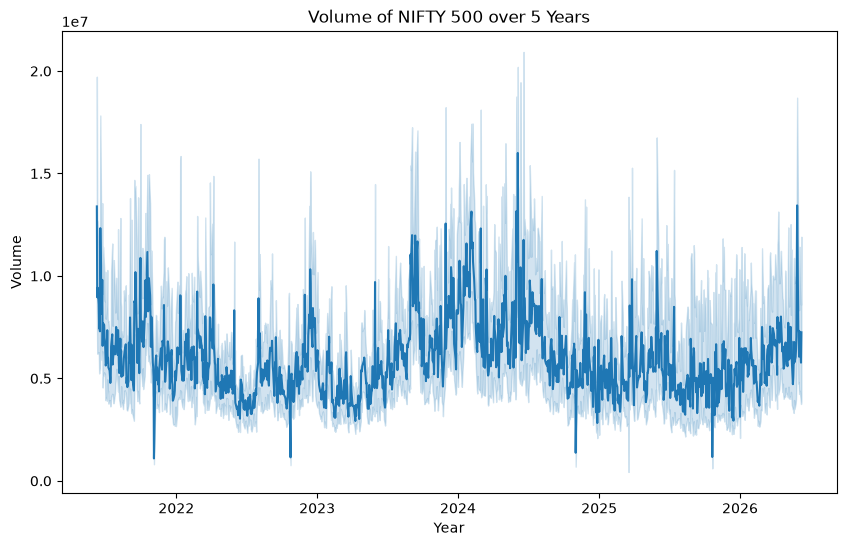

In [36]:
#date vs volume trend
sns.lineplot(data = df, x ="date", y="volume")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.title("Volume of NIFTY 500 over 5 Years")
plt.show()

- Volume trend is spreded widely with low and high jumps continously signifying a very normal and general trend

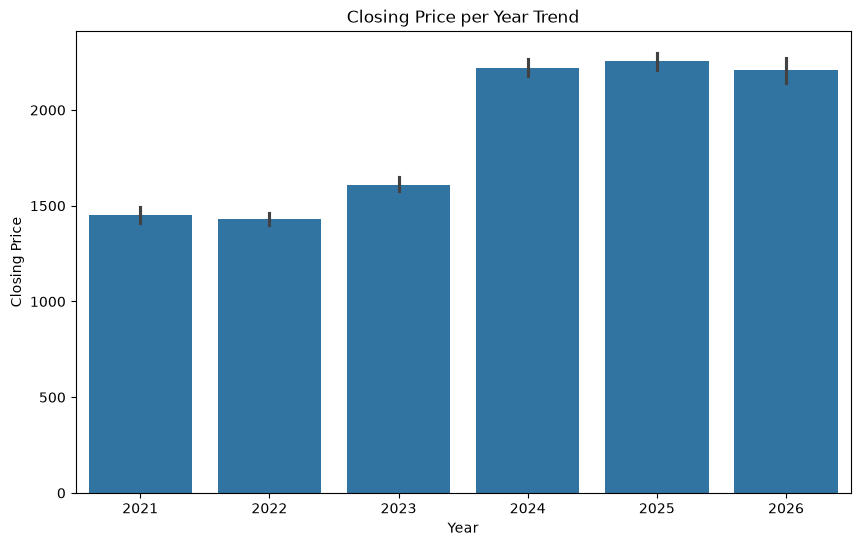

In [37]:
sns.barplot(data=df , x = "year" , y="close")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.title("Closing Price per Year Trend")
plt.show()

- Closing price is increased after 2023 showing a strong upward shift across all tickers.

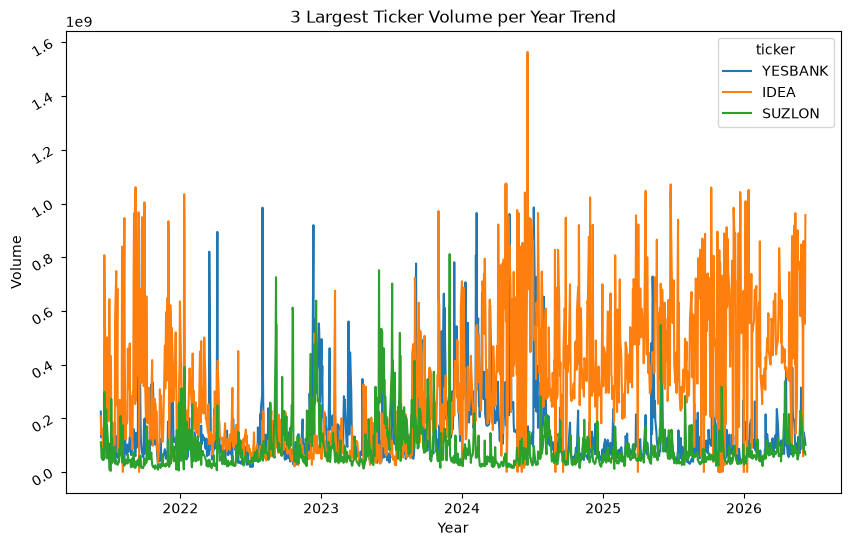

<Figure size 1000x600 with 0 Axes>

In [38]:
top_tickers = df.groupby("ticker")["volume"].mean().nlargest(3).index
subset = df[df["ticker"].isin(top_tickers)]
sns.lineplot(data=subset, x="date", y="volume", hue="ticker")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.title("3 Largest Ticker Volume per Year Trend")
plt.yticks(rotation = 30)
plt.show()

plt.tight_layout()

- IDEA have highest volume per year values among all the companies and YESBANK and SUZLON on second ans third.

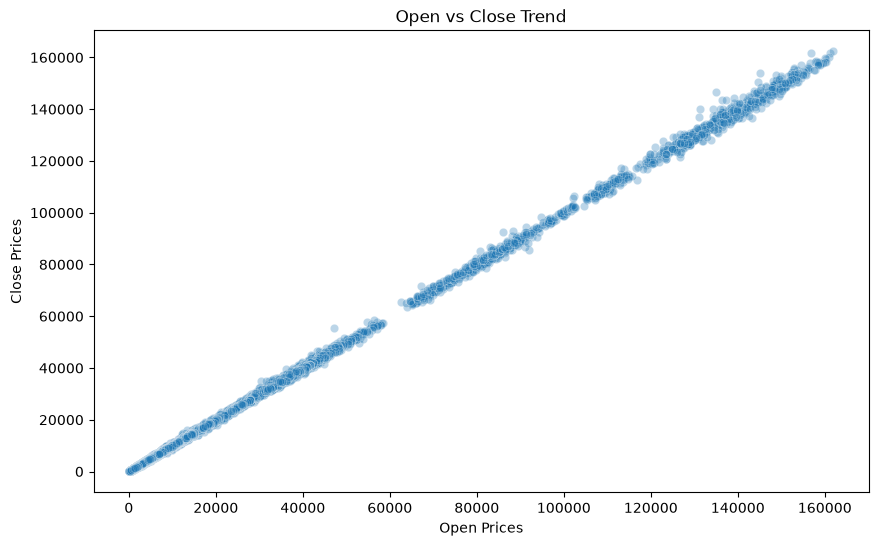

In [39]:
sns.scatterplot(data= df , x = "open", y = "close", alpha = 0.3)
plt.xlabel("Open Prices")
plt.ylabel("Close Prices")
plt.title("Open vs Close Trend")
plt.show()

- There is almost linear relation between open and close prices signifying there is no much volatility in a day.

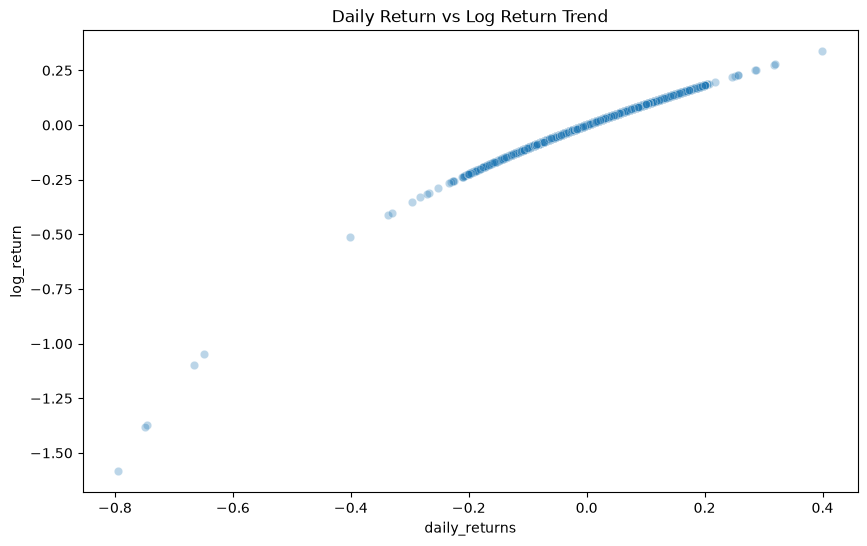

In [40]:
sns.scatterplot(data= df , x = "daily_returns", y = "log_return", alpha = 0.3)
plt.xlabel("daily_returns")
plt.ylabel("log_return")
plt.title("Daily Return vs Log Return Trend")
plt.show()

- There is almost linear realationship between daily_returns and log_returns because they have same purpose although mathematically they are different.

### Key Findings from Bivariate Analysis

- The average closing price trend shows increasing trend from 2021 to 2026.
- Volume trend is spreded widely with low and high jumps continously.
- Closing Price increased after 2023 significantly.
- IDEA have highest volume per year values, YESBANK second, SUZLON third.
- Linear relationship between:
   - open and close price 
   - daily_returns and log_return

# 9. Multivariate Analysis
In this section, we examine relationships between three or more variables simultaneously to uncover deeper patterns in the stock market.

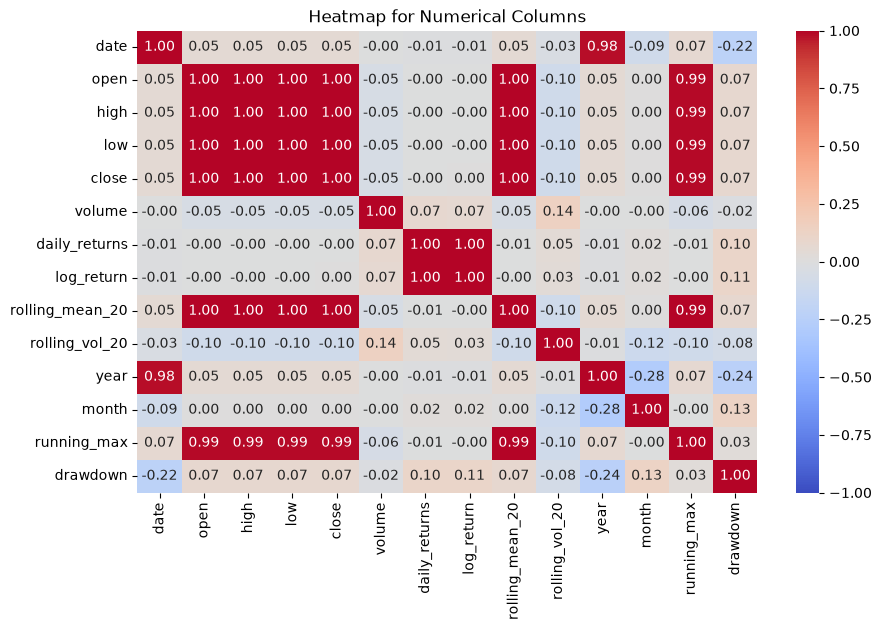

In [41]:
numeric_col = ['date','open','high','low','close','volume',
'daily_returns','log_return','rolling_mean_20','rolling_vol_20','year','month','running_max','drawdown']

corr = df[numeric_col].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt = '.2f')
plt.title("Heatmap for Numerical Columns")
plt.show()

- open, close, high,low, rolling_mean_20, running_max are all nearly perfectly correlated with values close to 1.00 which means they all move together.
- volume is mostly weak correlated with other columns, that means there not much impact of volume in the data set with prices.
- drawdown is also not correalted that much which is expected as it tells the decline seen in the prices.

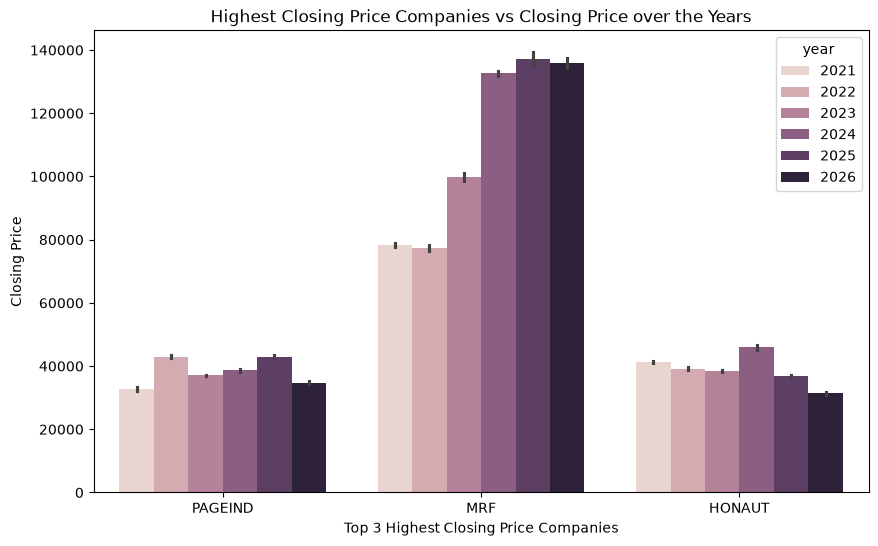

In [53]:
high_ticker = df.groupby("ticker")["close"].mean().nlargest(3).index
subset = df[df["ticker"].isin(high_ticker)]

sns.barplot(data = subset , x="ticker", y="close", hue="year")
plt.xlabel("Top 3 Highest Closing Price Companies")
plt.ylabel("Closing Price")
plt.title("Highest Closing Price Companies vs Closing Price over the Years")
plt.show()

- MRF as have significantly higher closing price over the 5 years across all the companies, follwing by PAGEIND second and HONAUT third.

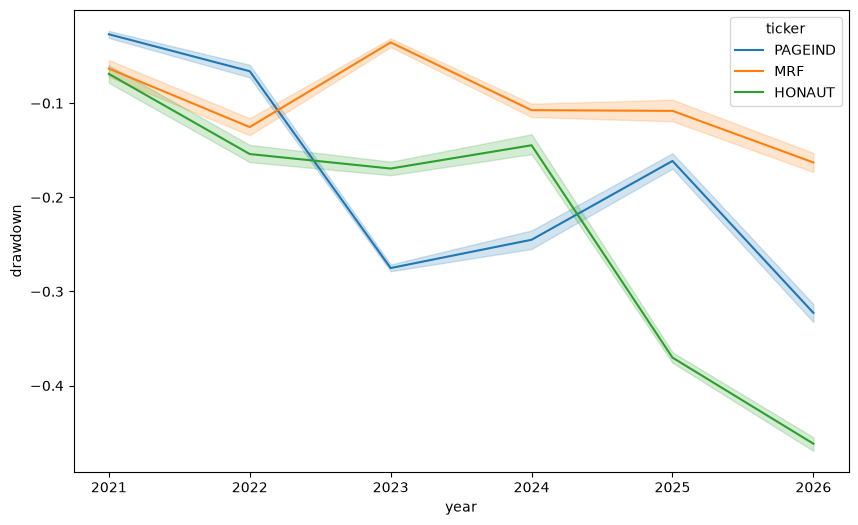

In [55]:
high_ticker = df.groupby("ticker")["close"].mean().nlargest(3).index
subset = df[df["ticker"].isin(high_ticker)]
sns.lineplot(data=subset,x="year",y="drawdown",hue="ticker",)
plt.show()

- MRF have lowest draw drawdown after 2022 among all the companies which signifies stable stock price, where as PAGEIND ans HONAUT varying over the years. 

### Key Findings from Multivariate Analysis

- All price realted columns have almost perfectly correlated except volume and drawdown.
- MRF as have significantly higher closing price over the 5 years.
- MRF have lowest draw drawdown after 2022 among all the companies.

## 10. Key Findings
The most important patterns observed in the analysis are summarized below:

- Strong upward trend in NIFTY 500 from 2021-2026 with 2023 being a turning point
- Price stability exists within trading days but significant volatility across time periods
- Few premium-priced stocks (MRF, PAGEIND, HONAUT) dominate the index
- Volume trading concentrated in specific stocks (IDEA, YESBANK, SUZLON)
- Market experienced major correction around 2025 but recovered.


## 11. Conclusion & Next Steps

- This analysis highlights stability within trading days but significant variability across longer periods, Future work can extend this EDA into predictive modeling and deeper stock market analysis.